In [4]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
%matplotlib inline

In [5]:
df = yf.download('BTC-USD', start='2020-01-01')
veridataframe = df[['Close']].copy()

veridataframe['SMA_20'] = veridataframe['Close'].rolling(window=20).mean() #20 günlük hareketli ortalama
veridataframe['SMA_50'] = veridataframe['Close'].rolling(window=50).mean() #50 günlük hareketli ortalama
veridataframe['SMA_200'] = veridataframe['Close'].rolling(window=200).mean() #200 günlük hareketli ortalama
veridataframe['Standard_Deviation'] = veridataframe['Close'].rolling(window=20).std()

veridataframe = veridataframe.dropna() #NaN değerlerini kaldırmak için
veridataframe['Trend'] = (veridataframe['SMA_20'] > veridataframe['SMA_50']).astype(int) #Trend sütunu, SMA_50'nin SMA_200'den büyük olup olmadığını kontrol eder. Büyükse 1, değilse 0 olarak atanır.
veridataframe['Signal'] = veridataframe['Trend'].diff() #Signal sütunu, Trend sütunundaki değişiklikleri gösterir. Trend değiştiğinde 1 veya -1 olur, aksi takdirde 0 kalır.
veridataframe['Lower_Standard_Deviation'] = veridataframe['SMA_20'] - 2*(veridataframe['Standard_Deviation'])
veridataframe['Top_Standard_Deviation'] = veridataframe['SMA_20'] + 2*(veridataframe['Standard_Deviation'])

[*********************100%***********************]  1 of 1 completed


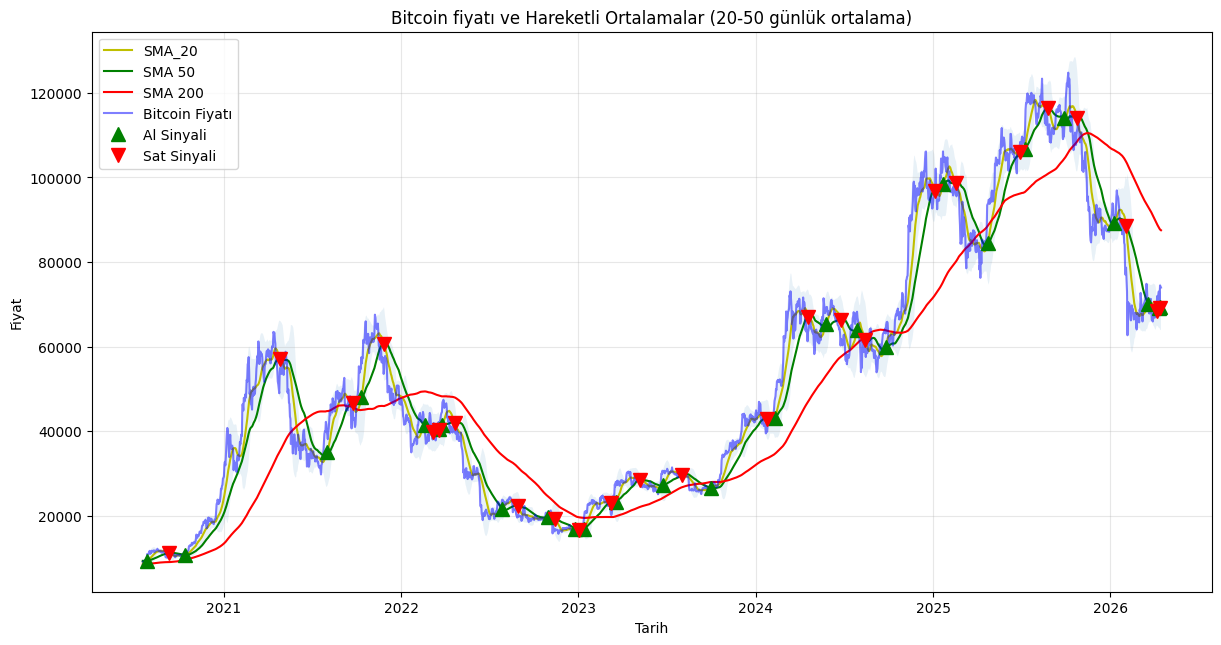

In [8]:
fig = plt.figure(figsize=(14,7))
ax = fig.add_axes([0.1,0.1,0.8,0.8])

ax.plot(veridataframe.index,veridataframe['SMA_20'],"y",label="SMA_20") #sma 20'yi sarı renkte çiz
ax.plot(veridataframe.index,veridataframe['SMA_50'],"g",label="SMA 50") #sma 50'yi yeşil renkte çiz
ax.plot(veridataframe.index,veridataframe['SMA_200'],"r",label="SMA 200") #sma 200'ü kırmızı renkte çiz
ax.plot(veridataframe.index,veridataframe['Close'],"b", alpha = 0.5, label="Bitcoin Fiyatı") #bitcoin fiyatını mavi renkte çiz
ax.fill_between(veridataframe.index,veridataframe['Top_Standard_Deviation'],veridataframe['Lower_Standard_Deviation'], alpha = 0.1)

al_sinyalleri = veridataframe[veridataframe['Signal'] == 1]
sat_sinyalleri = veridataframe[veridataframe['Signal'] == -1]

ax.plot(al_sinyalleri.index, al_sinyalleri['SMA_20'], "^", markersize=10, color='g', label='Al Sinyali') #al sinyallerini yeşil üçgenlerle göster
ax.plot(sat_sinyalleri.index, sat_sinyalleri['SMA_20'], "v", markersize=10, color='r', label='Sat Sinyali') #sat sinyallerini kırmızı ters üçgenlerle göster

ax.set_title("Bitcoin fiyatı ve Hareketli Ortalamalar (20-50 günlük ortalama)")
ax.set_xlabel("Tarih")
ax.set_ylabel("Fiyat")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show() 

In [ ]:
fig.savefig("bitcoin_fiyat_ve_hareketli_ortalamalar(20-50).png" , dpi=300)